In [1]:
# Notebook 03 -- Supplementary exploration: metformin/LDL gradient within Cluster 0
# This is explicitly secondary/exploratory and does not revisit the K=3 decision
# (Phase 3, already finalized and committed).

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

import sys
sys.path.append("../src")
from plot_style import set_project_style
set_project_style()

patient_features = pd.read_parquet("../data/processed/patient_features_clustered.parquet")

cluster0 = patient_features[patient_features["cluster_label"] == "Mild, lower treatment intensity"].copy()
print(f"Cluster 0 subset: {cluster0.shape[0]} patients")

Cluster 0 subset: 1303 patients


In [2]:
# Step 2 (per plan): compare on_metformin=0 vs on_metformin=1 within Cluster 0,
# across the lipid/glycemic panel -- not just LDL, to check whether the
# difference is an isolated artifact or a coherent metabolic signal.
# Mann-Whitney U (not a t-test): several of these variables are right-skewed
# (Phase 3 EDA). Rank-biserial r reported alongside p-value: with n=1303, even
# small, clinically negligible differences can reach statistical significance,
# so the effect size matters more than the p-value alone here.

panel_cols = ["LDL", "HDL", "Triglycerides", "HbA1c", "Glucose", "BMI"]

group0 = cluster0[cluster0["on_metformin"] == 0]
group1 = cluster0[cluster0["on_metformin"] == 1]

results = []
for col in panel_cols:
    u_stat, p_value = mannwhitneyu(group0[col], group1[col], alternative="two-sided")
    n0, n1 = len(group0), len(group1)
    rank_biserial = 1 - (2 * u_stat) / (n0 * n1)
    results.append({
        "variable": col,
        "median_no_metformin": group0[col].median(),
        "median_on_metformin": group1[col].median(),
        "p_value": round(p_value, 4),
        "rank_biserial_r": round(rank_biserial, 3),
    })

pd.DataFrame(results)

,variable,median_no_metformin,median_on_metformin,p_value,rank_biserial_r
0,LDL,131.50,103.9,0.0,-0.429
1,HDL,50.20,53.4,0.0,0.158
2,Triglycerides,170.15,128.7,0.0,-0.683
3,HbA1c,6.90,5.9,0.0,-0.580
4,Glucose,111.45,84.2,0.0,-0.793
5,BMI,27.80,30.0,0.0,0.661


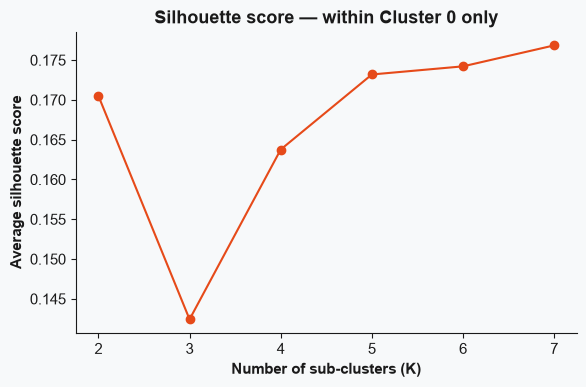

In [3]:
# Step 3 (per plan): recursive clustering within Cluster 0 only, on continuous
# clinical features (on_metformin excluded as input -- profiling variable, not
# a clustering feature, same logic as the main analysis).
#
# IMPORTANT: RobustScaler is re-fit on this subset alone, not reused from the
# full-cohort scaler. Cluster 0 is, by construction, the low-severity slice of
# the cohort -- reusing the global scale would compress whatever internal
# variation exists here even further, hiding exactly the structure we're
# trying to detect.

from sklearn.preprocessing import RobustScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

continuous_cols = [
    "AGE", "HbA1c", "Glucose", "BMI", "LDL", "HDL",
    "Triglycerides", "Creatinine", "CCI", "encounters_per_year_log",
]

cluster0_scaled = cluster0[continuous_cols].copy()
local_scaler = RobustScaler()
cluster0_scaled[continuous_cols] = local_scaler.fit_transform(cluster0_scaled[continuous_cols])

k_range = range(2, 8)
local_silhouettes = []
for k in k_range:
    labels = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(cluster0_scaled)
    local_silhouettes.append(silhouette_score(cluster0_scaled, labels))

plt.figure(figsize=(6, 4))
plt.plot(list(k_range), local_silhouettes, marker="o", color="#E64A19")
plt.title("Silhouette score — within Cluster 0 only")
plt.xlabel("Number of sub-clusters (K)")
plt.ylabel("Average silhouette score")
plt.tight_layout()
plt.show()